In [2]:
# ===============================================================
# CELL 1 : SETUP + DATA ACQUISITION
# [UNIT I: Introduction to ML and Pre-requisites]
# ===============================================================

!pip install kaggle -q

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from zipfile import ZipFile
from PIL import Image

# ML / DL Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# ------------------------------------------------
# Kaggle API Token Authentication
# ------------------------------------------------
os.environ["KAGGLE_API_TOKEN"] = "KGAT_2e3f21a9ec3d1a4493dd5a29c36bf726"

# Download PlantVillage Dataset
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -q

# Extract Dataset
with ZipFile("plantvillage-dataset.zip", "r") as zip_ref:
    zip_ref.extractall()

# Dataset Path
base_dir = "plantvillage dataset/color"
class_names = os.listdir(base_dir)

print(f"✅ Dataset Ready. Found {len(class_names)} Classes")

TensorFlow Version: 2.20.0
GPU Available: []
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
✅ Dataset Ready. Found 38 Classes


In [3]:
# ===============================================================
# CELL 2 : CLASSICAL ML BASELINE
# [UNIT II, IV, V]
# ===============================================================

print("Preparing subset for Classical ML baseline...")

X_cls, y_cls = [], []
subset_classes = class_names[:5]

for label_idx, cls_name in enumerate(subset_classes):
    cls_path = os.path.join(base_dir, cls_name)

    for img_name in os.listdir(cls_path)[:150]:
        img = Image.open(os.path.join(cls_path, img_name)).convert("RGB").resize((64,64))
        X_cls.append(np.array(img).flatten())
        y_cls.append(label_idx)

X_cls = np.array(X_cls)
y_cls = np.array(y_cls)

from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

# PCA
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_pca, y_train_c)

rf_acc = rf.score(X_test_pca, y_test_c)

print(f"✅ Classical ML Accuracy: {rf_acc*100:.2f}%")
print("Proceeding to Deep Learning...")

Preparing subset for Classical ML baseline...
✅ Classical ML Accuracy: 85.33%
Proceeding to Deep Learning...


In [4]:
# ===============================================================
# CELL 3 : DEEP LEARNING MODEL (BEST VERSION)
# [UNIT III + V]
# ===============================================================

img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_gen = train_datagen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

val_gen = train_datagen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical',
    shuffle=False
)

# Save Class Mapping
class_indices = {v:k for k,v in train_gen.class_indices.items()}

with open("class_indices.json", "w") as f:
    json.dump(class_indices, f)

# ---------------- Base Model ----------------
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
# ===============================================================
# CELL 4 : TRAINING PHASE
# ===============================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=9,   # Can use 8 or 9
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# Save Final Model
model.save("plant_disease_model.h5")

print("✅ Training Complete")

Epoch 1/9
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6636 - loss: 1.2189
Epoch 1: val_accuracy improved from None to 0.90893, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2179s 2s/step - accuracy: 0.7710 - loss: 0.7707 - val_accuracy: 0.9089 - val_loss: 0.2946 - learning_rate: 0.0010
Epoch 2/9
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.8566 - loss: 0.4429
Epoch 2: val_accuracy improved from 0.90893 to 0.91787, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1323s 974ms/step - accuracy: 0.8599 - loss: 0.4314 - val_accuracy: 0.9179 - val_loss: 0.2480 - learning_rate: 0.0010
Epoch 3/9
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.8748 - loss: 0.3799
Epoch 3: val_accuracy improved from 0.91787 to 0.92644, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1295s 954ms/step - accuracy: 0.8772 - loss: 0.3775 - val_accuracy: 0.9264 - val_loss: 0.2171 - learning_rate: 0.0010
Epoch 4/9
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.8845 - loss: 0.3495
Epoch 4: val_accuracy improved from 0.92644 to 0.93170, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1283s 945ms/step - accuracy: 0.8863 - loss: 0.3466 - val_accuracy: 0.9317 - val_loss: 0.2044 - learning_rate: 0.0010
Epoch 5/9
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.8877 - loss: 0.3404
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_accuracy improved from 0.93170 to 0.93188, saving model to best_model.h5


...


Epoch 6: finished saving model to best_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1330s 950ms/step - accuracy: 0.9108 - loss: 0.2696 - val_accuracy: 0.9369 - val_loss: 0.1766 - learning_rate: 5.0000e-04
Epoch 7/9
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 994ms/step - accuracy: 0.9152 - loss: 0.2590
Epoch 7: val_accuracy improved from 0.93686 to 0.94313, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1820s 1s/step - accuracy: 0.9155 - loss: 0.2549 - val_accuracy: 0.9431 - val_loss: 0.1705 - learning_rate: 5.0000e-04
Epoch 8/9
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9190 - loss: 0.2439
Epoch 8: val_accuracy improved from 0.94313 to 0.94322, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2368s 2s/step - accuracy: 0.9180 - loss: 0.2448 - val_accuracy: 0.9432 - val_loss: 0.1689 - learning_rate: 5.0000e-04
Epoch 9/9
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9166 - loss: 0.2416
Epoch 9: val_accuracy improved from 0.94322 to 0.94414, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1731s 1s/step - accuracy: 0.9188 - loss: 0.2401 - val_accuracy: 0.9441 - val_loss: 0.1639 - learning_rate: 5.0000e-04


✅ Training Complete


340/340 ━━━━━━━━━━━━━━━━━━━━ 251s 734ms/step
------ Classification Report ------
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.92      0.93      0.92       126
                                 Apple___Black_rot       0.97      0.94      0.96       124
                          Apple___Cedar_apple_rust       0.96      0.96      0.96        55
                                   Apple___healthy       0.97      0.98      0.98       329
                               Blueberry___healthy       0.99      0.99      0.99       300
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      0.99       210
                 Cherry_(including_sour)___healthy       0.97      0.97      0.97       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.78      0.78      0.78       102
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       23

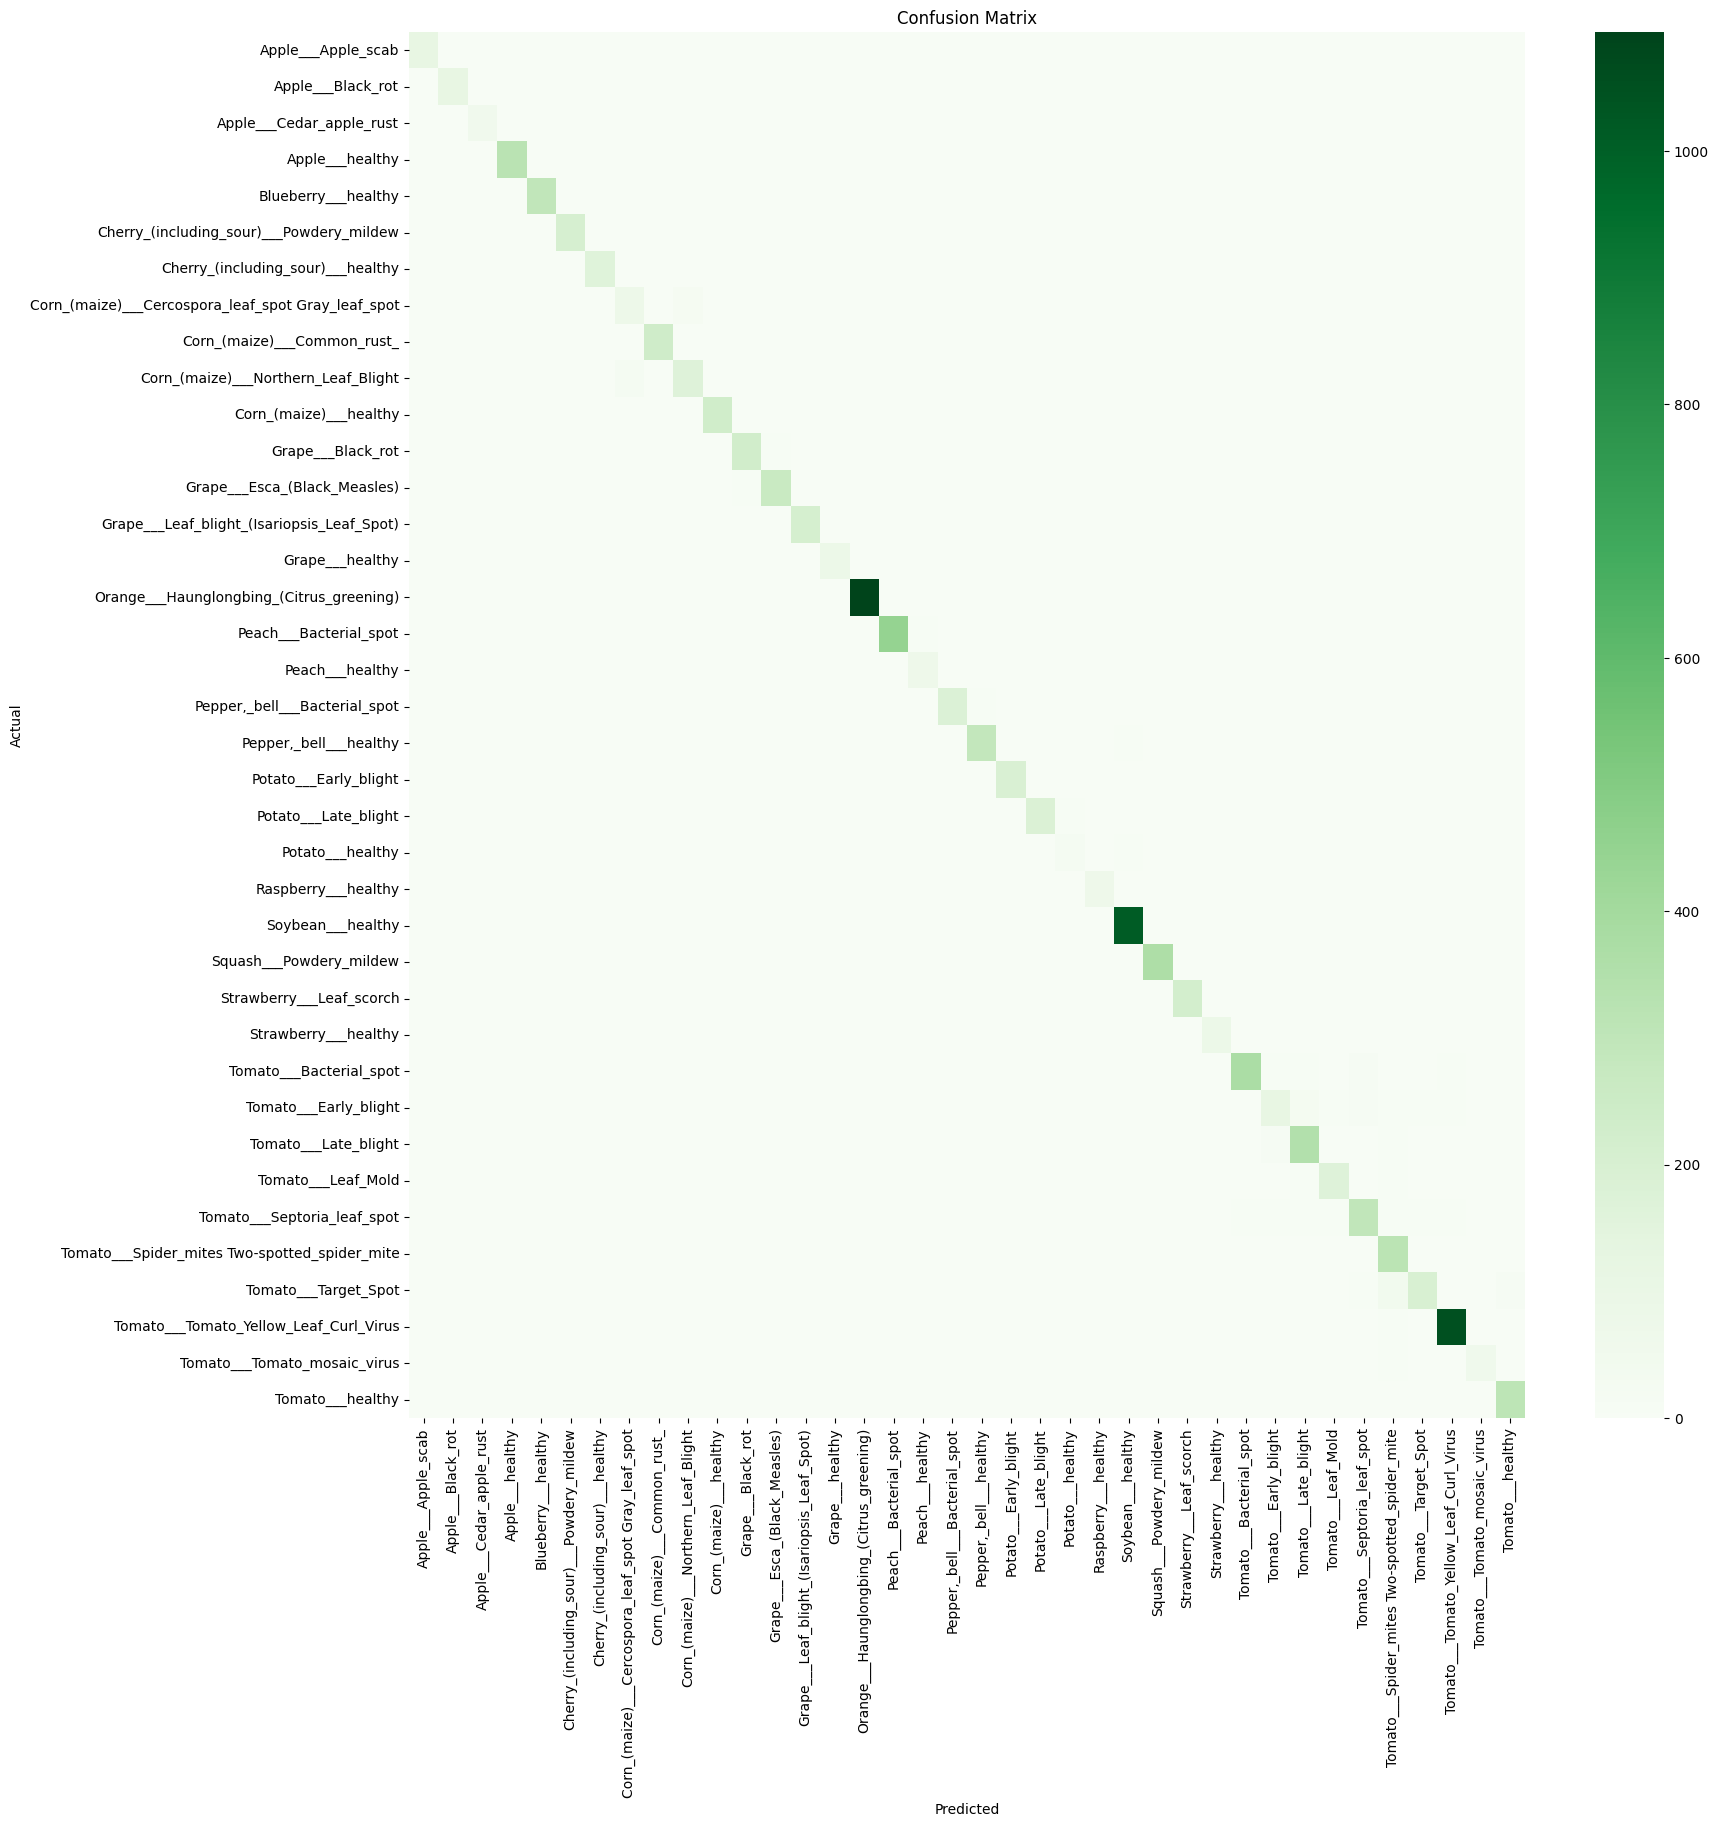

In [6]:
# ===============================================================
# CELL 5 : EVALUATION
# [UNIT III + V]
# ===============================================================

predictions = model.predict(val_gen, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = val_gen.classes

labels = list(val_gen.class_indices.keys())

print("------ Classification Report ------")
print(classification_report(y_true, y_pred, target_names=labels))

# Confusion Matrix
plt.figure(figsize=(18,18))

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(
    cm,
    cmap='Greens',
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.show()

In [1]:
import tensorflow as tf
model = tf.keras.models.load_model("best_model.h5", compile=False)
print("Loaded")

Loaded


In [1]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow as tf
import numpy as np
import json
from PIL import Image

# Load model
model = tf.keras.models.load_model("best_model.h5", compile=False)

# Load labels
with open("class_indices.json", "r") as f:
    labels = json.load(f)

# Paste image path here
file_path = input("Paste image path here: ")

# Load image
img = Image.open(file_path).convert("RGB").resize((224,224))

arr = np.array(img).astype("float32") / 255.0
arr = np.expand_dims(arr, axis=0)

# Predict
preds = model.predict(arr, verbose=0)[0]

top_idx = np.argmax(preds)
confidence = preds[top_idx] * 100

prediction = labels[str(top_idx)]
prediction = prediction.replace("___"," - ").replace("_"," ")

print("Prediction :", prediction)
print("Confidence :", round(confidence,2), "%")

Paste image path here:  k


FileNotFoundError: [Errno 2] No such file or directory: 'k'

In [2]:
import os
print(os.getcwd())

C:\Users\shiva


In [3]:
import os
print(os.listdir())

['.anaconda', '.android', '.bash_history', '.cache', '.conda', '.condarc', '.continuum', '.copilot', '.dotnet', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.kaggle', '.keras', '.lesshst', '.m2', '.matplotlib', '.nbi', '.redhat', '.rsp', '.streamlit', '.templateengine', '.th-client', '.TurboVPN', '.VirtualBox', '.vscode', 'anaconda3', 'app.py', 'AppData', 'Application Data', 'assistance', 'best_model.h5', 'bookstore', 'bookstoreClone', 'boston_housing.csv', 'Classified Data (1)', 'class_indices.json', 'computers.csv', 'Contacts', 'Cookies', 'Credit_Risk_Test_Data.csv', 'Credit_Risk_Train_Data.csv', 'Credit_Risk_Validate_Data.csv', 'CyberBullying Comments Dataset.csv', 'Cyberbullying-detection', 'cyberCBP.ipynb', 'decision_tree_algorithm.ipynb', 'delivery.csv', 'Documents', 'Downloads', 'Favorites', 'ImportWorkshop', 'k means clustering.ipynb', 'KNN.ipynb', 'labelEncoder.ipynb', 'linear_regression.ipynb', 'Links', 'Loan Prediction.csv', 'loanML.ipynb', 'loan_d